<a href="https://colab.research.google.com/github/Chandrani45/MDTS4312_708/blob/main/Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv("/content/Synthetic.csv")

In [ ]:
df.head()

,Unnamed: 0,X,Y
0,0,37.454012,126.746701
1,1,95.071431,293.927975
2,2,73.199394,225.441700
3,3,59.865848,183.586508
4,4,15.601864,39.020372


In [ ]:
data=df.drop(columns=["Unnamed: 0"])

In [ ]:
data.head()

,X,Y
0,37.454012,126.746701
1,95.071431,293.927975
2,73.199394,225.441700
3,59.865848,183.586508
4,15.601864,39.020372


BATCH GRADIENT

In [ ]:
class Gradient:
 def __init__(self):
    self.learning_rate = 0.0001
    self.epochs = 10000
    self.tolerance = 0.001
    self.epoch = 1
    self.loss = 1
    self.losses = []
 def preprocess(self):
    self.x=data.iloc[:,0].values
    self.y=data.iloc[:,1].values
    return (self.x,self.y)
 def reshape(self):
    self.x = self.x.reshape(1, -1)
    self.y = self.y.reshape(-1, 1)
    return (self.x,self.y)
 def standardize(self):
     self.x = (self.x - np.mean(self.x)) / np.std(self.x)
 def initialise_parameters(self):
    self.theta_0 = np.array(np.random.randn()).reshape(1,1)
    self.theta_1 = np.array(np.random.randn()).reshape(1,1)
 def calculate(self):
    m=50
    while self.epoch <= self.epochs and self.loss > self.tolerance:

     # Forward pass
      self.y_hat = self.theta_0 * self.x + self.theta_1

    # Loss calculation
      self.loss = 1/2 * np.mean((self.y_hat.T - self.y)**2)

    # derivative calculation
      self.d_theta_0 = 1/m * np.dot(self.x, (self.y_hat.T - self.y))
      self.d_theta_1 = 1/m * np.sum(self.y_hat.T - self.y)

    # Update parameters
      self.theta_0 = self.theta_0 - self.learning_rate * self.d_theta_0
      self.theta_1 = self.theta_1 - self.learning_rate * self.d_theta_1

      self.losses.append(self.loss)

      self.epoch += 1
    return (self.theta_0,self.theta_1,self.losses)

In [ ]:
if __name__ == "__main__":
    gradient=Gradient()
    gradient.preprocess()
    gradient.reshape()
    gradient.standardize()
    gradient.initialise_parameters()
    (theta_0,theta_1,losses)=gradient.calculate()

In [ ]:
print(theta_0[0][0])
print(theta_1[0][0])
print(losses)

54.01764226971848
89.27840671764895
[np.float64(13411.5927732767), np.float64(13408.918819137874), np.float64(13406.245399763136), np.float64(13403.57251504554), np.float64(13400.90016487816), np.float64(13398.22834915409), np.float64(13395.557067766444), np.float64(13392.88632060836), np.float64(13390.216107573004), np.float64(13387.546428553553), np.float64(13384.877283443207), np.float64(13382.208672135193), np.float64(13379.540594522758), np.float64(13376.87305049916), np.float64(13374.206039957691), np.float64(13371.53956279166), np.float64(13368.8736188944), np.float64(13366.208208159262), np.float64(13363.543330479613), np.float64(13360.878985748852), np.float64(13358.215173860395), np.float64(13355.551894707674), np.float64(13352.889148184151), np.float64(13350.226934183309), np.float64(13347.565252598644), np.float64(13344.904103323679), np.float64(13342.243486251962), np.float64(13339.583401277045), np.float64(13336.923848292527), np.float64(13334.26482719201), np.float64(133

Text(0, 0.5, 'Loss (MSE)')

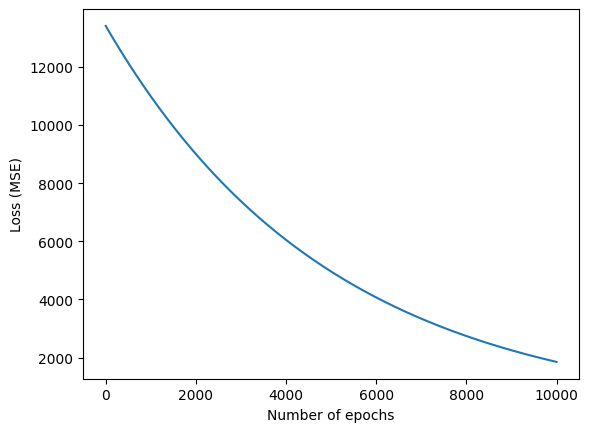

In [ ]:
plt.plot(losses)
plt.xlabel("Number of epochs")
plt.ylabel("Loss (MSE)")

STOCHASTIC GRADIENT DESCENT

In [73]:
class SGradient:
 def __init__(self):
    self.learning_rate = 0.0001
    self.epochs = 10000
    self.tolerance = 0.001
    self.epoch = 1
    self.loss = 1
 def preprocess(self):
    self.x=data.iloc[:,0].values
    self.y=data.iloc[:,1].values
    return (self.x,self.y)
 def standardize(self):
     self.x = (self.x - np.mean(self.x)) / np.std(self.x)
 def initialise_parameters(self):
    self.theta_0 = np.array(np.random.randn())
    self.theta_1 = np.array(np.random.randn())
 def calculate(
 self):
    self.losses=[]
    while self.epoch <= self.epochs and self.loss > self.tolerance:
         epoch_loss=0
         for i in range(self.x.shape[0]):
           idx=np.random.randint(0,self.x.shape[0])
           self.y_hat=self.x[idx]*self.theta_1+self.theta_0
           self.loss = 1/2*(self.y_hat - self.y[idx])**2
    # derivative calculation
           self.d_theta_1=  self.x[idx]*(self.y_hat - self.y[idx])
           self.d_theta_0 = (self.y_hat - self.y[idx])
           self.theta_0 = self.theta_0 - self.learning_rate * self.d_theta_0
           self.theta_1 = self.theta_1 - self.learning_rate * self.d_theta_1
           epoch_loss+=self.loss
         self.epoch += 1
         avg_loss = epoch_loss / self.x.shape[0]
         self.losses.append(avg_loss)
    return self.theta_0,self.theta_1,self.losses

In [74]:
if __name__ == "__main__":
    gradient=SGradient()
    gradient.preprocess()
    gradient.standardize()
    gradient.initialise_parameters()
    (theta_0,theta_1,losses)=gradient.calculate()

In [75]:
print(theta_0)
print(theta_1)

129.0071348710384
77.87368978973919


Text(0, 0.5, 'Loss (MSE)')

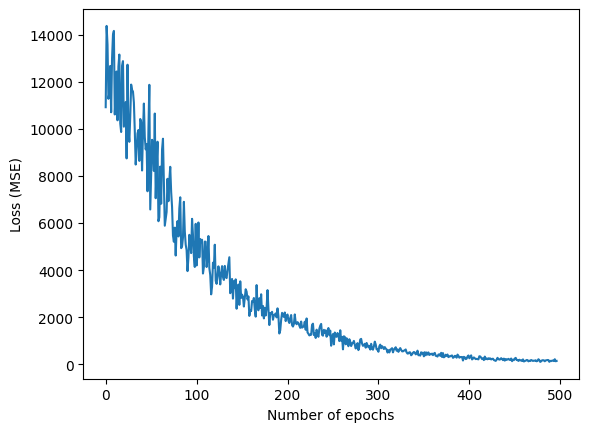

In [76]:
plt.plot(losses)
plt.xlabel("Number of epochs")
plt.ylabel("Loss (MSE)")

MINI BATCH GRADIENT DESCENT

In [81]:
class MBGradient:
 def __init__(self,batch_size):
    self.learning_rate = 0.0001
    self.epochs = 10000
    self.tolerance = 0.001
    self.epoch = 1
    self.loss = 1
    self.batch_size=batch_size

    self.losses = []
 def preprocess(self):
    self.x=data.iloc[:,0].values
    self.y=data.iloc[:,1].values
    return (self.x,self.y)
 def standardize(self):
     self.x = (self.x - np.mean(self.x)) / np.std(self.x)
 def initialise_parameters(self):
    self.theta_0 = np.array(np.random.randn())
    self.theta_1 = np.array(np.random.randn())
 def calculate(self):
    m=self.batch_size
    while self.epoch <= self.epochs and self.loss > self.tolerance:
         epoch_loss=0
         num_batches=1
         for i in range(int(self.x.shape[0]/self.batch_size)):
          idx = np.random.choice(self.x.shape[0], self.batch_size, replace=False)
          self.y_hat=self.x[idx]*self.theta_1+self.theta_0

    # Loss calculation
          batch_loss = 1/2 * np.mean((self.y_hat - self.y[idx])**2)
          num_batches+=1
          epoch_loss+=batch_loss
    # derivative calculation
          self.d_theta_1 = 1/m * np.dot(self.x[idx], (self.y_hat - self.y[idx]))
          self.d_theta_0 = 1/m * np.sum(self.y_hat - self.y[idx])

    # Update parameters
          self.theta_0 = self.theta_0 - self.learning_rate * self.d_theta_0
          self.theta_1 = self.theta_1 - self.learning_rate * self.d_theta_1

          self.loss= epoch_loss/num_batches
          self.losses(self.loss)
          self.epoch += 1
    return (self.theta_0,self.theta_1,self.losses)

In [82]:
if __name__ == "__main__":
    gradient=MBGradient(batch_size=10)
    gradient.preprocess()
    gradient.standardize()
    gradient.initialise_parameters()
    (theta_0,theta_1,losses)=gradient.calculate()

In [83]:
print(theta_0)
print(theta_1)

89.49568615514197
54.439437531285954


Text(0, 0.5, 'Loss (MSE)')

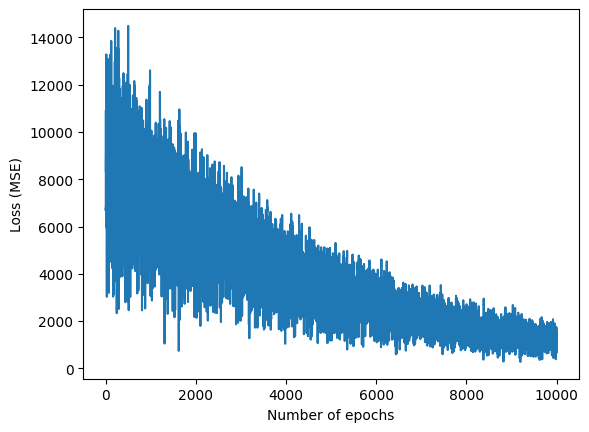

In [84]:
plt.plot(losses)
plt.xlabel("Number of epochs")
plt.ylabel("Loss (MSE)")